# Step-by-step: mitochondria segmentation on EM slices with nnU-Net

This notebook demonstrates, end to end, how the vendored [nnU-Net](https://github.com/MIC-DKFZ/nnUNet)
copy in this repository is used to segment mitochondria in volume electron microscopy
(vEM) images of human liver tissue (organelle-level segmentation, see the main
[README](../../README.md)).

It walks through:

1. Loading a few example EM image patches (cropped from the same periportal human
   liver vEM dataset used in the manuscript).
2. Loading a trained nnU-Net checkpoint for mitochondria segmentation.
3. Running inference with the Python API (equivalent to the `nnUNetv2_predict` CLI
   described in the main README).
4. Visualising the predicted masks next to the raw EM data and the expert
   ground-truth annotation available for this example region.

**Note on the example data:** the three crops below are taken from a training slice
for which a manual mitochondria annotation is available in this repository, so that
predictions can be checked against ground truth without requiring any additional
downloads. The mechanics shown here (loading a checkpoint, calling
`predict_from_files`, visualising the output) are identical when applied to new,
unlabelled EM slices &mdash; see Section 5 for how to point this at your own data.

**Note on checkpoints:** trained nnU-Net checkpoints for all segmented organelles are
available on [Zenodo](https://zenodo.org/records/17360859) (see main README,
"Installation", step 5). Update `MODEL_FOLDER` in Section 2 below to point at wherever
you extracted the downloaded checkpoint.

In [1]:
import os
import sys
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread

# Silence environment-specific runtime warnings (e.g. CUDA availability
# checks on machines without a GPU) that are irrelevant to this demo.
warnings.filterwarnings("ignore", category=UserWarning)

# Make the vendored `nnunetv2` package (one level up from this notebook)
# importable without installing it.
REPO_ROOT = os.path.abspath("..")
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import torch

# The checkpoints released with this project were saved with an older
# PyTorch/NumPy combination. PyTorch >= 2.6 defaults `torch.load(...,
# weights_only=True)`, which rejects that older pickle format. We trust
# these checkpoints (they ship with this repository / its Zenodo record),
# so we restore the previous default for this notebook only.
_torch_load = torch.load


def _load_full(*args, **kwargs):
    kwargs.setdefault("weights_only", False)
    return _torch_load(*args, **kwargs)


torch.load = _load_full

from nnunetv2.inference.predict_from_raw_data import nnUNetPredictor

print("nnU-Net import OK. Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())

nnUNet_raw is not defined and nnU-Net can only be used on data for which preprocessed files are already present on your system. nnU-Net cannot be used for experiment planning and preprocessing like this. If this is not intended, please read documentation/setting_up_paths.md for information on how to set this up properly.
nnUNet_preprocessed is not defined and nnU-Net can not be used for preprocessing or training. If this is not intended, please read documentation/setting_up_paths.md for information on how to set this up.
nnUNet_results is not defined and nnU-Net cannot be used for training or inference. If this is not intended behavior, please read documentation/setting_up_paths.md for information on how to set this up.
nnU-Net import OK. Torch: 2.6.0 | CUDA available: False


## 1. Example EM slices

`notebooks/example_data/` contains three 768&times;768 px crops taken directly from one
of the training images, i.e. real, full-resolution (8 nm/pixel) periportal human liver
EM data &mdash; the same tissue and imaging resolution the mitochondria model was
trained on. Each crop is named following nnU-Net's input convention:
`<case_identifier>_0000.png` (channel `0000` = the single "EM" input channel defined
in `dataset.json`).

Found 3 example EM crops: ['em_crop_A', 'em_crop_B', 'em_crop_C']


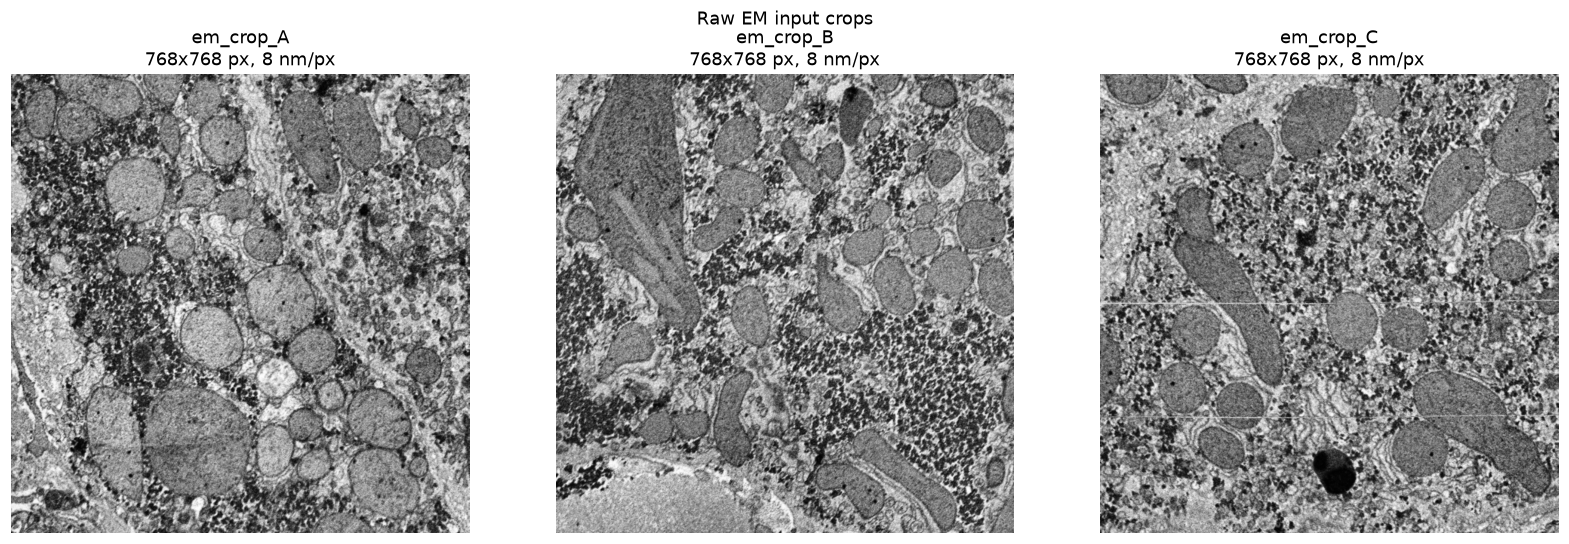

In [2]:
EXAMPLE_DATA_DIR = "example_data"
EXAMPLE_GT_DIR = "example_data_gt"  # ground-truth masks, kept out of the nnU-Net input folder

case_ids = sorted(
    fn[: -len("_0000.png")]
    for fn in os.listdir(EXAMPLE_DATA_DIR)
    if fn.endswith("_0000.png")
)
print(f"Found {len(case_ids)} example EM crops: {case_ids}")

fig, axes = plt.subplots(1, len(case_ids), figsize=(5 * len(case_ids), 5))
for ax, case_id in zip(axes, case_ids):
    img = imread(os.path.join(EXAMPLE_DATA_DIR, f"{case_id}_0000.png"))
    ax.imshow(img, cmap="gray")
    ax.set_title(f"{case_id}\n{img.shape[1]}x{img.shape[0]} px, 8 nm/px")
    ax.axis("off")
fig.suptitle("Raw EM input crops")
plt.tight_layout()
plt.show()

## 2. Load the trained nnU-Net model checkpoint

We use the same `nnUNetPredictor` class that backs the `nnUNetv2_predict` command-line
tool. `MODEL_FOLDER` should point at a trained-model output directory, i.e. the folder
that directly contains `dataset.json`, `plans.json`, and one `fold_<n>/` per trained
fold (see `documentation/setting_up_paths.md`).

If you downloaded checkpoints from [Zenodo](https://zenodo.org/records/17360859),
set `MODEL_FOLDER` to the extracted folder for the mitochondria segmentation model
(the one directly containing `dataset.json`, `plans.json`, and a `fold_<n>/`
subdirectory). No GPU is required &mdash; this notebook runs on CPU by default
(`DEVICE = "cpu"`); switch to `"cuda"` for much faster inference if a GPU is
available.

In [3]:
# Update this to wherever you extracted the Zenodo checkpoint download for the
# mitochondria segmentation model (see main README, "Installation", step 5).
# For this demo, `mitochondria_2d_checkpoint` is a local symlink (not tracked
# in the repository, see .gitignore) pointing at that extracted folder.
MODEL_FOLDER = "mitochondria_2d_checkpoint"
DEVICE = "cpu"  # set to "cuda" if a GPU is available, for much faster inference

predictor = nnUNetPredictor(
    tile_step_size=0.5,
    use_gaussian=True,
    use_mirroring=True,
    perform_everything_on_device=(DEVICE == "cuda"),
    device=torch.device(DEVICE),
    verbose=False,
    allow_tqdm=True,
)

t0 = time.time()
predictor.initialize_from_trained_model_folder(
    MODEL_FOLDER,
    use_folds=("all",),  # this checkpoint was trained on a single "all" fold
    checkpoint_name="checkpoint_final.pth",
)
print(f"Loaded checkpoint from {MODEL_FOLDER} in {time.time() - t0:.1f}s")
print("Labels:", predictor.dataset_json["labels"])

perform_everything_on_device=True is only supported for cuda devices! Setting this to False
Loaded checkpoint from mitochondria_2d_checkpoint in 3.1s
Labels: {'background': 0, 'mito': 1}


## 3. Run inference

`predict_from_files` is nnU-Net's standard batch-prediction entry point: it reads every
case in the input folder, runs the trained model (sliding-window inference with
test-time mirroring and Gaussian tile weighting, matching the settings used for the
manuscript), and writes one segmentation PNG per case to the output folder. This is
exactly what happens under the hood when you run:

```bash
nnUNetv2_predict -i notebooks/example_data -o notebooks/example_output \
  -d <DATASET_ID> -c 2d -f all -chk checkpoint_final.pth
```

In [4]:
OUTPUT_DIR = "example_output"

t0 = time.time()
predictor.predict_from_files(
    EXAMPLE_DATA_DIR,
    OUTPUT_DIR,
    save_probabilities=False,
    overwrite=True,
    num_processes_preprocessing=1,
    num_processes_segmentation_export=1,
)
print(f"Predicted {len(case_ids)} crop(s) in {time.time() - t0:.1f}s")
print("Output files:", sorted(os.listdir(OUTPUT_DIR)))

name of the source_folder: example_data
There are 3 cases in the source folder
I am process 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 3 cases that I would like to predict

Predicting em_crop_A:
perform_everything_on_device: False
sending off prediction to background worker for resampling and export
done with em_crop_A

Predicting em_crop_B:
perform_everything_on_device: False
sending off prediction to background worker for resampling and export
done with em_crop_B

Predicting em_crop_C:
perform_everything_on_device: False
sending off prediction to background worker for resampling and export
done with em_crop_C
Predicted 3 crop(s) in 29.1s
Output files: ['dataset.json', 'em_crop_A.png', 'em_crop_B.png', 'em_crop_C.png', 'plans.json', 'predict_from_raw_data_args.json']


100%|##########| 4/4 [00:07<00:00,  1.93s/it]


## 4. Visualise predictions vs. ground truth

For each crop we show the raw EM input, the predicted mitochondria mask overlaid in
red, and (since this example region has an expert annotation) the ground-truth mask
overlaid in green, plus the Dice coefficient between the two.

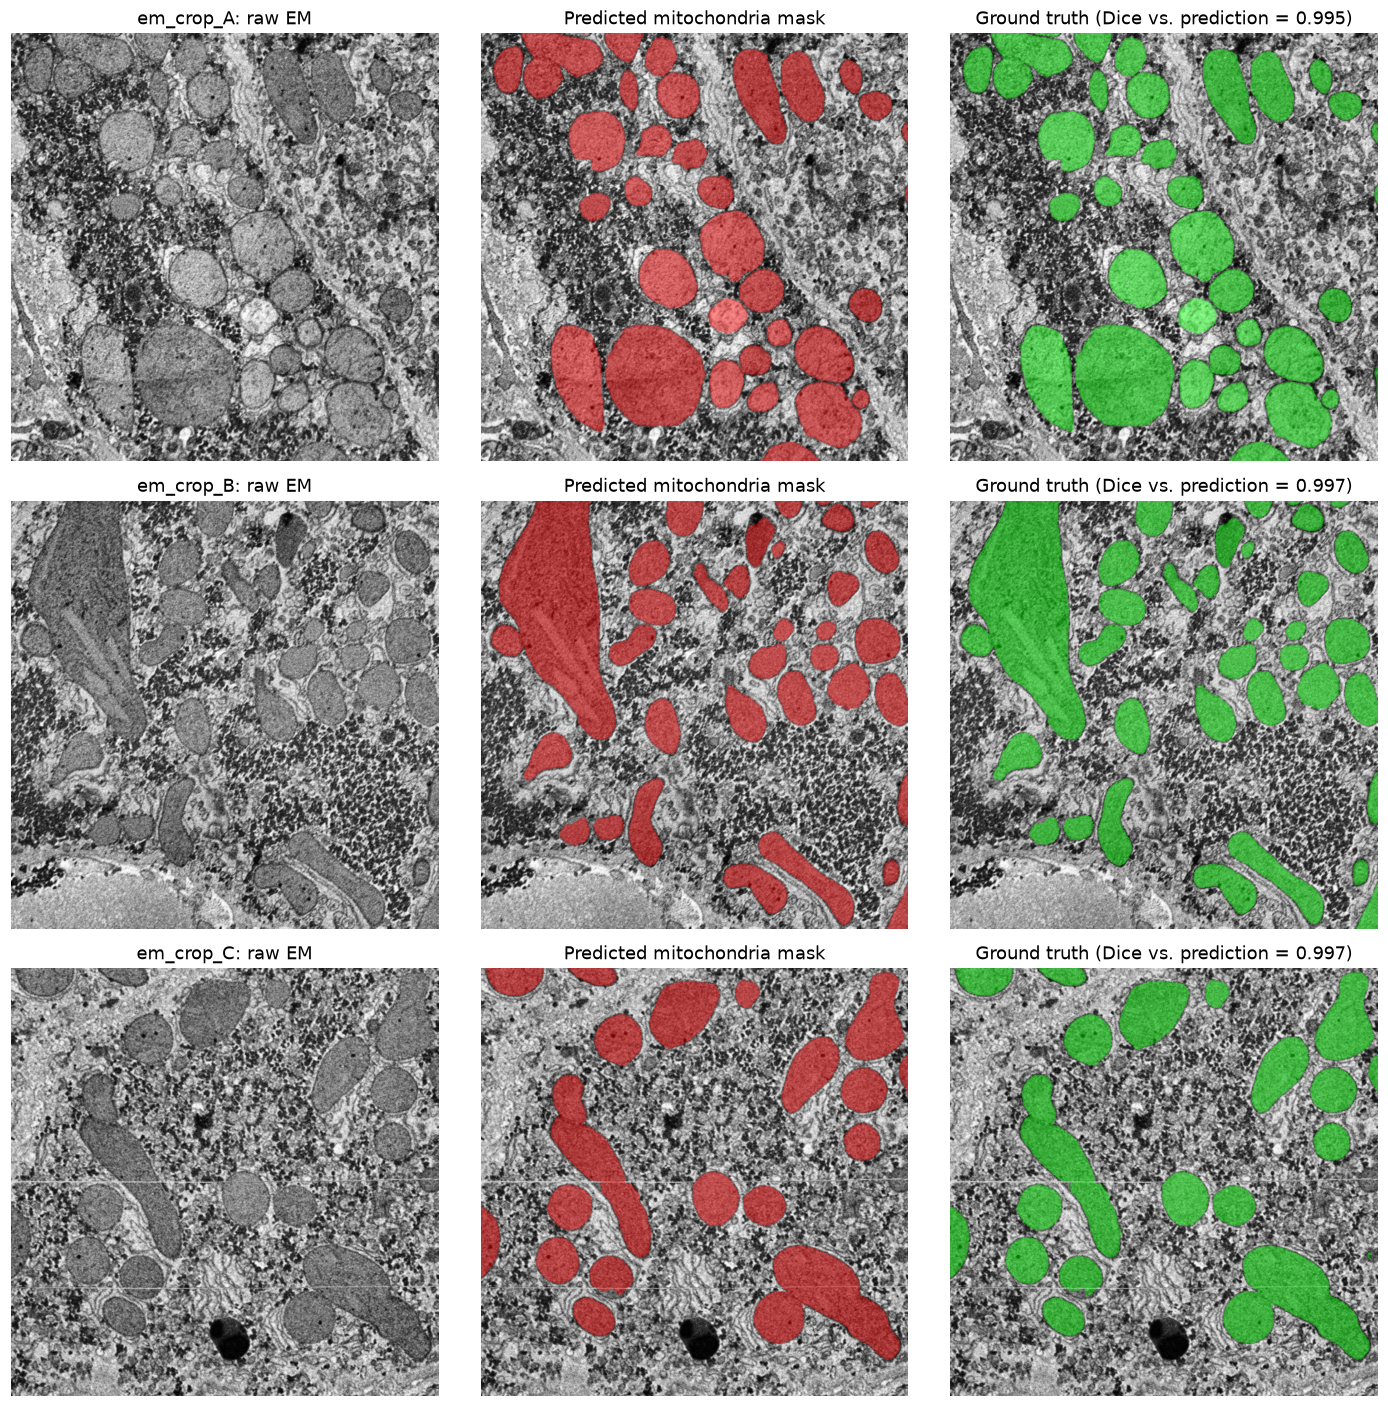

In [5]:
def overlay(ax, image, mask, color, alpha=0.45):
    rgba = np.zeros((*mask.shape, 4))
    rgba[mask > 0] = (*color, alpha)
    ax.imshow(image, cmap="gray")
    ax.imshow(rgba)


fig, axes = plt.subplots(len(case_ids), 3, figsize=(13, 4.3 * len(case_ids)))
if len(case_ids) == 1:
    axes = axes[None, :]

for row, case_id in enumerate(case_ids):
    img = imread(os.path.join(EXAMPLE_DATA_DIR, f"{case_id}_0000.png"))
    pred = imread(os.path.join(OUTPUT_DIR, f"{case_id}.png")) > 0
    gt_path = os.path.join(EXAMPLE_GT_DIR, f"{case_id}_gt_mask.png")
    gt = (imread(gt_path) > 0) if os.path.exists(gt_path) else None

    axes[row, 0].imshow(img, cmap="gray")
    axes[row, 0].set_title(f"{case_id}: raw EM")
    axes[row, 0].axis("off")

    overlay(axes[row, 1], img, pred, color=(1, 0, 0))
    axes[row, 1].set_title("Predicted mitochondria mask")
    axes[row, 1].axis("off")

    if gt is not None:
        dice = 2 * (pred & gt).sum() / (pred.sum() + gt.sum())
        overlay(axes[row, 2], img, gt, color=(0, 1, 0))
        axes[row, 2].set_title(f"Ground truth (Dice vs. prediction = {dice:.3f})")
    else:
        axes[row, 2].imshow(img, cmap="gray")
        axes[row, 2].set_title("No ground truth available for this crop")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

## 5. Running on your own EM slices

To segment new, unlabelled data:

1. Arrange your EM slices as `<case_id>_0000.png` (or `.tif`/other formats supported by
   nnU-Net's `NaturalImage2DIO`/`SimpleITKIO` readers) in a single input folder — one
   file per 2D slice, at the same pixel size the model was trained on (8 nm/px for the
   mitochondria model used here).
2. Point `MODEL_FOLDER` above at the checkpoint for the organelle you want to segment
   (other organelles, e.g. ER, nucleus, are listed in the main README / Zenodo record).
3. Re-run Sections 2&ndash;4 with your input folder in place of `example_data`.

For large volumes it is much faster to run this on a GPU (`DEVICE = "cuda"`) and via
the `nnUNetv2_predict` CLI with multiple preprocessing/export workers, as shown in the
main README's "Organelle Segmentation" section.